# LEBESGUE/RIEMANN-STIELTJES-STOCHASTIC

## 3-subplot figure

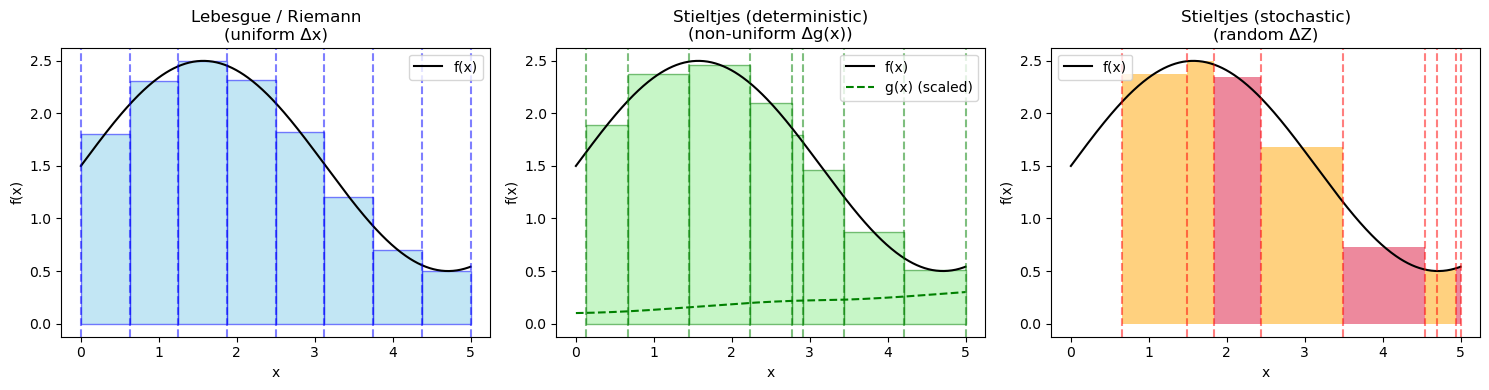

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Function to integrate
x = np.linspace(0, 5, 400)
f = np.sin(x) + 1.5

fig, ax = plt.subplots(1, 3, figsize=(15,4))

# --- 1. Lebesgue/Riemann: uniform partitions ---
ax[0].plot(x, f, 'k', label='f(x)')
ax[0].set_title("Lebesgue / Riemann\n(uniform Δx)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("f(x)")
Nrects = 8
xs = np.linspace(0, 5, Nrects+1)
for i in range(Nrects):
    xi = xs[i]
    xi1 = xs[i+1]
    xm = 0.5*(xi+xi1)
    height = np.sin(xm) + 1.5
    ax[0].add_patch(plt.Rectangle((xi,0), xi1-xi, height, facecolor='skyblue', edgecolor='b', alpha=0.5))
for xi in xs:
    ax[0].axvline(xi, color='b', linestyle='--', alpha=0.5)
ax[0].legend()

# --- 2. Stieltjes: deterministic nonuniform partitions ---
g_vals = np.cumsum(np.abs(np.sin(np.linspace(0,5,Nrects+1)))+0.2)
g_scaled = g_vals/g_vals[-1]*5
ax[1].plot(x, f, 'k', label='f(x)')
ax[1].set_title("Stieltjes (deterministic)\n(non-uniform Δg(x))")
ax[1].set_xlabel("x"); ax[1].set_ylabel("f(x)")
for i in range(Nrects):
    xi = g_scaled[i]
    xi1 = g_scaled[i+1]
    xm = 0.5*(xi+xi1)
    height = np.sin(xm) + 1.5
    ax[1].add_patch(plt.Rectangle((xi,0), xi1-xi, height, facecolor='lightgreen', edgecolor='g', alpha=0.5))
for xi in g_scaled:
    ax[1].axvline(xi, color='g', linestyle='--', alpha=0.5)
# overlay g(x)
xg = np.linspace(0,5,200)
g_curve = np.cumsum(np.abs(np.sin(xg))+0.2)
g_curve = g_curve/g_curve[-1]*5
ax[1].plot(xg, 0.1+0.2*g_curve/g_curve.max(), 'g--', label='g(x) (scaled)')
ax[1].legend()

# --- 3. Stochastic Stieltjes: random increments ---
np.random.seed(3)
rand_increments = np.random.rand(Nrects+1)
rand_scaled = np.cumsum(rand_increments)
rand_scaled = rand_scaled/rand_scaled[-1]*5
ax[2].plot(x, f, 'k', label='f(x)')
ax[2].set_title("Stieltjes (stochastic)\n(random ΔZ)")
ax[2].set_xlabel("x"); ax[2].set_ylabel("f(x)")
for i in range(Nrects):
    xi = rand_scaled[i]
    xi1 = rand_scaled[i+1]
    xm = 0.5*(xi+xi1)
    height = np.sin(xm) + 1.5
    # random weight could be signed: show with varying color intensity
    weight = (np.random.randn())*0.5
    color = 'crimson' if weight > 0 else 'orange'
    ax[2].add_patch(plt.Rectangle((xi,0), xi1-xi, height, facecolor=color, alpha=0.5))
for xi in rand_scaled:
    ax[2].axvline(xi, color='r', linestyle='--', alpha=0.5)
ax[2].legend()

plt.tight_layout()
plt.savefig('01_Lebesgue_Stieltjes_integrals.svg')
plt.show()

## 4-subplot figure

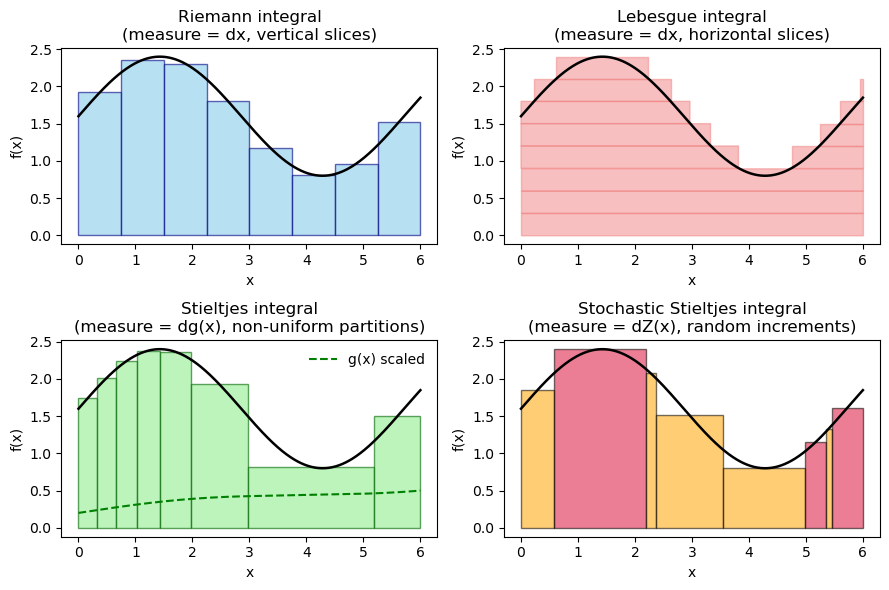

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Function to integrate
x = np.linspace(0, 6, 600)
f = 0.8*np.sin(1.1*x) + 1.6  # positive

fig, ax = plt.subplots(2, 2, figsize=(9, 6))

# ------------------------------
# 1) Riemann Integral
# ------------------------------
ax[0,0].plot(x, f, 'k', lw=1.8)
ax[0,0].set_title("Riemann integral\n(measure = dx, vertical slices)")
N = 8
xs = np.linspace(0, 6, N+1)
for i in range(N):
    x0, x1 = xs[i], xs[i+1]
    xm = 0.5*(x0+x1)
    height = 0.8*np.sin(1.1*xm) + 1.6
    ax[0,0].add_patch(plt.Rectangle((x0, 0), x1-x0, height,
                                    facecolor='skyblue', edgecolor='navy', alpha=0.6))
ax[0,0].set_xlabel("x"); ax[0,0].set_ylabel("f(x)")

# ------------------------------
# 2) Lebesgue Integral (horizontal slicing)
# ------------------------------
ax[0,1].plot(x, f, 'k', lw=1.8)
ax[0,1].set_title("Lebesgue integral\n(measure = dx, horizontal slices)")
M = 8
ys = np.linspace(0, f.max(), M+1)
for i in range(M):
    y0, y1 = ys[i], ys[i+1]
    # horizontal strip between y0 and y1
    mask = f >= y0
    x_span = x[mask]
    if len(x_span) > 0:
        ax[0,1].fill_between(x, y0, y1, where=(f >= y0),
                             color='lightcoral', alpha=0.5, step='mid')
ax[0,1].set_xlabel("x"); ax[0,1].set_ylabel("f(x)")

# ------------------------------
# 3) Stieltjes Integral (deterministic g)
# ------------------------------
ax[1,0].plot(x, f, 'k', lw=1.8)
ax[1,0].set_title("Stieltjes integral\n(measure = dg(x), non-uniform partitions)")
N = 8
# Define monotone g(x) to induce partitions
xg = np.linspace(0, 6, 800)
g_curve = np.cumsum(np.maximum(np.gradient(0.5*xg + 0.6*np.sin(0.8*xg)), 1e-3))
g_curve = (g_curve - g_curve.min())/(g_curve.max()-g_curve.min())
s_edges = np.linspace(0, 1, N+1)
x_edges = np.interp(s_edges, g_curve, xg)
for i in range(N):
    x0, x1 = x_edges[i], x_edges[i+1]
    xm = 0.5*(x0+x1)
    height = 0.8*np.sin(1.1*xm) + 1.6
    ax[1,0].add_patch(plt.Rectangle((x0,0), x1-x0, height,
                                    facecolor='lightgreen', edgecolor='darkgreen', alpha=0.6))
ax[1,0].plot(xg, 0.3*(g_curve-g_curve.min())+0.2, 'g--', label="g(x) scaled")
ax[1,0].legend(frameon=False, loc='upper right')
ax[1,0].set_xlabel("x"); ax[1,0].set_ylabel("f(x)")

# ------------------------------
# 4) Stochastic Stieltjes Integral
# ------------------------------
ax[1,1].plot(x, f, 'k', lw=1.8)
ax[1,1].set_title("Stochastic Stieltjes integral\n(measure = dZ(x), random increments)")
N = 8
rng = np.random.default_rng(2)
dZ_pos = rng.random(N+1)+1e-3
x_edges_rand = np.cumsum(dZ_pos)
x_edges_rand = (x_edges_rand-x_edges_rand.min())/(x_edges_rand.max()-x_edges_rand.min())*6.0
weights = rng.normal(0,1,N)
for i in range(N):
    x0, x1 = x_edges_rand[i], x_edges_rand[i+1]
    xm = 0.5*(x0+x1)
    height = 0.8*np.sin(1.1*xm) + 1.6
    color = 'crimson' if weights[i]>=0 else 'orange'
    ax[1,1].add_patch(plt.Rectangle((x0,0), x1-x0, height,
                                    facecolor=color, edgecolor='black', alpha=0.55))
ax[1,1].set_xlabel("x"); ax[1,1].set_ylabel("f(x)")

plt.tight_layout()
plt.savefig('02_Riemann_Lebesgue_Stieltjes_stochastic.svg')
plt.show()

# DIRICHLET FUNCTION'S LEBESGUE INTEGRAL

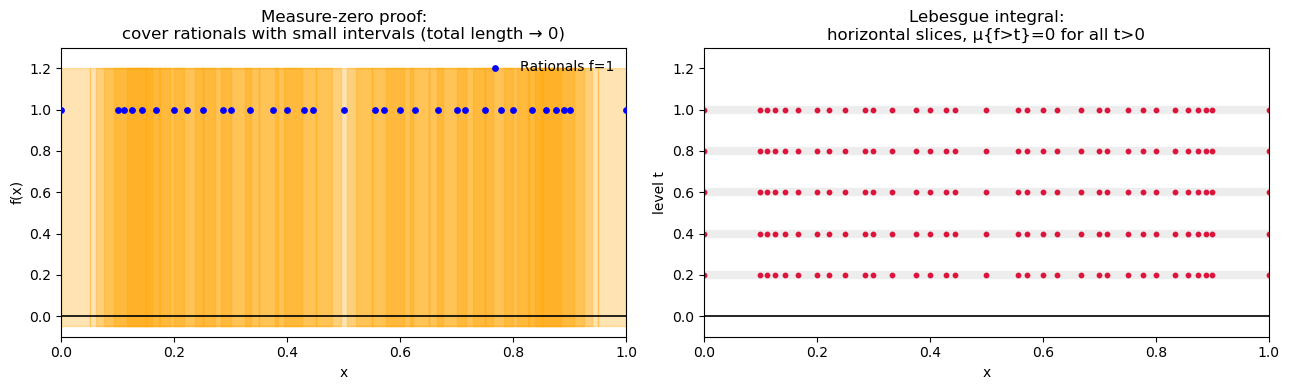

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

# Generate rationals in [0,1] with denominator ≤ Qmax
def rationals_up_to_den(Qmax):
    s = set()
    for q in range(1, Qmax+1):
        for p in range(0, q+1):
            r = Fraction(p, q)
            if 0 <= r <= 1:
                s.add(r)
    return sorted(float(r) for r in s)

Qmax = 10
rats = np.array(rationals_up_to_den(Qmax))

# Epsilon for covering intervals (measure-zero proof)
eps = 0.05

# Levels for horizontal slicing (Lebesgue definition)
t_levels = np.linspace(0.2, 1.0, 5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# -----------------------------
# Left: Measure-zero proof (interval covering)
# -----------------------------
x = np.linspace(0,1,500)
axes[0].plot(x, np.zeros_like(x), 'k-', lw=1.2)
axes[0].scatter(rats, np.ones_like(rats), s=15, color='blue', zorder=3, label="Rationals f=1")

# Cover rationals by orange intervals of half-width eps
for r in rats:
    left = max(0, r - eps)
    right = min(1, r + eps)
    axes[0].fill_between([left, right], -0.05, 1.2, color='orange', alpha=0.3)

axes[0].set_xlim(0,1); axes[0].set_ylim(-0.1, 1.3)
axes[0].set_title("Measure-zero proof:\ncover rationals with small intervals (total length → 0)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].legend(frameon=False, loc="upper right")

# -----------------------------
# Right: Lebesgue horizontal slicing (definition)
# -----------------------------
for t in t_levels:
    axes[1].hlines(t, 0, 1, colors='lightgray', linestyles='-', lw=6, alpha=0.4, zorder=1)
    axes[1].scatter(rats, t*np.ones_like(rats), s=10, color='crimson', zorder=2)

# baseline at y=0 (for t≤0 the whole interval contributes)
axes[1].hlines(0, 0, 1, colors='k', linestyles='-', lw=1.2)
axes[1].set_xlim(0,1); axes[1].set_ylim(-0.1, 1.3)
axes[1].set_title("Lebesgue integral:\nhorizontal slices, μ{f>t}=0 for all t>0")
axes[1].set_xlabel("x"); axes[1].set_ylabel("level t")

plt.tight_layout()
plt.savefig('03_Dirichlet_function_Lebesgue_integral.svg')
plt.show()

# DARBOUX SUMS

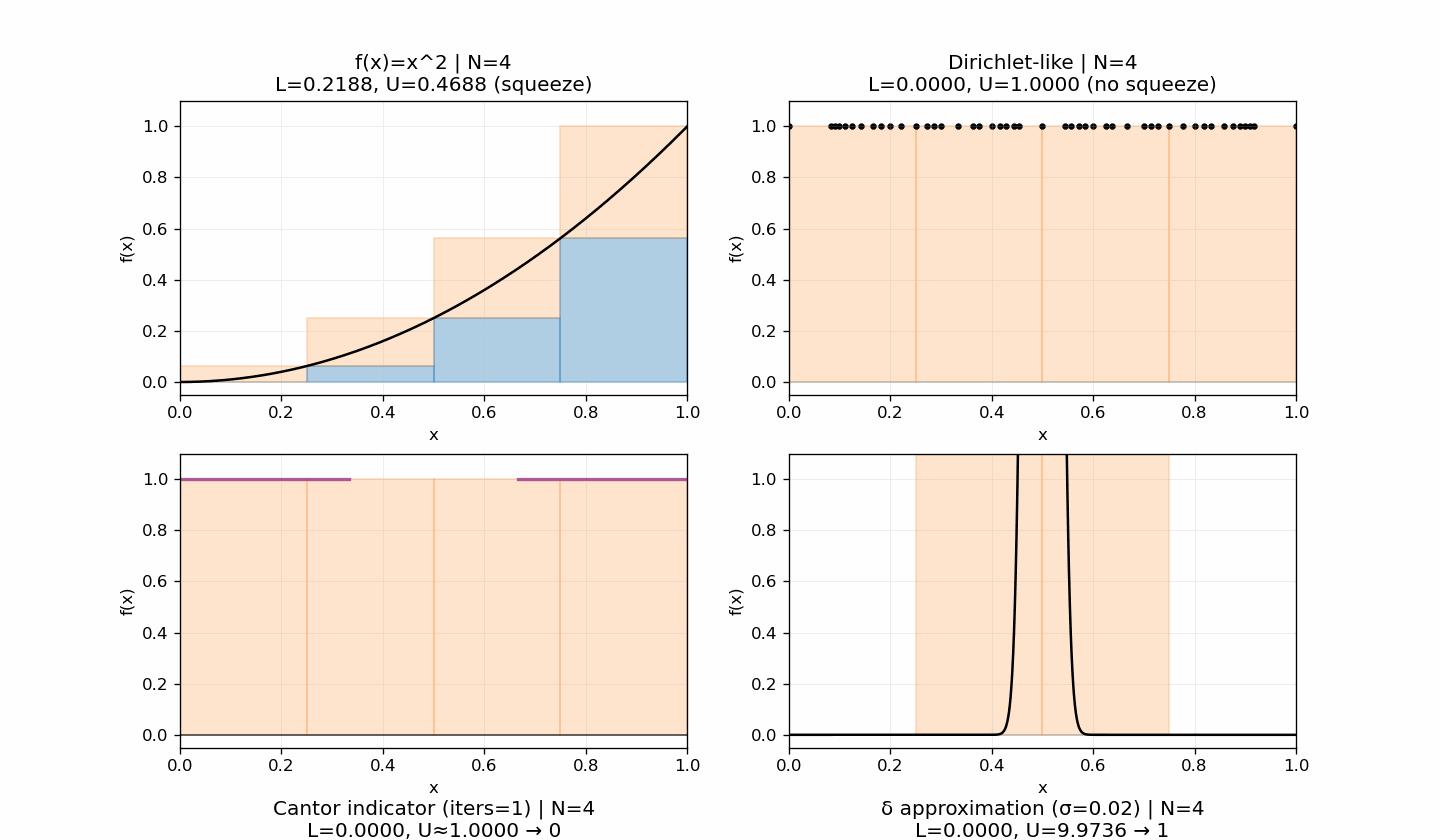

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.animation import PillowWriter
from IPython.display import Image as IPyImage, display

# -----------------------------
# Helper functions
# -----------------------------
def f_cont(x):
    return x**2

def dirichlet_like_sup_inf():
    # For any subinterval: inf = 0 (irrationals), sup = 1 (rationals)
    return 0.0, 1.0

def cantor_intervals(iters):
    """Return list of closed intervals approximating the Cantor set after 'iters' steps."""
    intervals = [(0.0, 1.0)]
    for _ in range(iters):
        new_ints = []
        for a, b in intervals:
            third = (b - a) / 3.0
            new_ints.append((a, a + third))
            new_ints.append((b - third, b))
        intervals = new_ints
    return intervals  # union of 2^iters closed intervals

def interval_intersects_any(a, b, intervals):
    """Check if [a,b] intersects any interval in 'intervals'."""
    for L, R in intervals:
        if not (b < L or a > R):
            return True
    return False

def draw_darboux_rects_continuous(ax, f, a, b, N):
    xs = np.linspace(a, b, 400)
    ax.plot(xs, f(xs), lw=1.5, color='k')
    parts = np.linspace(a, b, N+1)
    Lsum = Usum = 0.0
    for i in range(N):
        x0, x1 = parts[i], parts[i+1]
        sub_x = np.linspace(x0, x1, 300)
        vals = f(sub_x)
        m, M = np.min(vals), np.max(vals)
        ax.add_patch(patches.Rectangle((x0, 0.0), x1-x0, m, alpha=0.35, color='tab:blue'))
        ax.add_patch(patches.Rectangle((x0, m), x1-x0, M-m, alpha=0.20, color='tab:orange'))
        Lsum += m*(x1-x0); Usum += M*(x1-x0)
    return Lsum, Usum

def draw_darboux_rects_dirichlet(ax, a, b, N, rationals=None):
    parts = np.linspace(a, b, N+1)
    Lsum = Usum = 0.0
    for i in range(N):
        x0, x1 = parts[i], parts[i+1]
        m, M = dirichlet_like_sup_inf()
        ax.add_patch(patches.Rectangle((x0, 0.0), x1-x0, m, alpha=0.35, color='tab:blue'))
        ax.add_patch(patches.Rectangle((x0, m), x1-x0, M-m, alpha=0.20, color='tab:orange'))
        Lsum += m*(x1-x0); Usum += M*(x1-x0)
    # scatter a finite set of rationals for context
    if rationals is not None:
        ax.scatter(rationals, np.ones_like(rationals), s=8, color='k')
    return Lsum, Usum

def draw_darboux_rects_cantor(ax, a, b, N, iters):
    xs = np.linspace(a, b, 400)
    # draw an indicator sketch (optional thin line at 0)
    ax.plot(xs, np.zeros_like(xs), lw=1.0, color='k', alpha=0.6)
    C_ints = cantor_intervals(iters)
    parts = np.linspace(a, b, N+1)
    Lsum = Usum = 0.0
    for i in range(N):
        x0, x1 = parts[i], parts[i+1]
        width = x1 - x0
        # Lower bound m = 0 (every neighborhood contains complement, in the true Cantor indicator)
        m = 0.0
        # Upper bound M = 1 if interval intersects Cantor set approx, else 0
        M = 1.0 if interval_intersects_any(x0, x1, C_ints) else 0.0
        ax.add_patch(patches.Rectangle((x0, 0.0), width, m, alpha=0.35, color='tab:blue'))
        ax.add_patch(patches.Rectangle((x0, m), width, M-m, alpha=0.20, color='tab:orange'))
        Lsum += m*width; Usum += M*width
    # Draw Cantor intervals (thin purple bars at y=1 for context)
    for L, R in C_ints:
        ax.plot([L, R], [1.0, 1.0], color='purple', lw=2, alpha=0.6)
    return Lsum, Usum

def gaussian_delta(x, x0=0.5, sigma=0.02):
    norm = 1.0 / (np.sqrt(2*np.pi)*sigma)
    return norm * np.exp(-0.5*((x-x0)/sigma)**2)

def draw_darboux_rects_delta(ax, a, b, N, sigma=0.02):
    xs = np.linspace(a, b, 600)
    ax.plot(xs, gaussian_delta(xs, 0.5, sigma), lw=1.5, color='k')
    parts = np.linspace(a, b, N+1)
    Lsum = Usum = 0.0
    for i in range(N):
        x0, x1 = parts[i], parts[i+1]
        sub_x = np.linspace(x0, x1, 400)
        vals = gaussian_delta(sub_x, 0.5, sigma)
        m, M = np.min(vals), np.max(vals)
        ax.add_patch(patches.Rectangle((x0, 0.0), x1-x0, m, alpha=0.35, color='tab:blue'))
        ax.add_patch(patches.Rectangle((x0, m), x1-x0, M-m, alpha=0.20, color='tab:orange'))
        Lsum += m*(x1-x0); Usum += M*(x1-x0)
    return Lsum, Usum

# Finite set of rationals for Dirichlet context
def rationals_Qmax(Qmax=12):
    rats = set()
    from fractions import Fraction
    for q in range(1, Qmax+1):
        for p in range(0, q+1):
            rats.add(Fraction(p, q))
    return np.array(sorted(float(r) for r in rats if 0 <= r <= 1))

# -----------------------------
# Build GIF with four subplots
# -----------------------------
a, b = 0.0, 1.0
Ns = [4, 8, 16, 32, 64]
rats = rationals_Qmax(12)
sigma_delta = 0.02

gif_path = "04_Darboux_sums.gif"
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plt.close(fig)
writer = PillowWriter(fps=1)

with writer.saving(fig, gif_path, dpi=120):
    for N in Ns:
        for ax in axes.ravel():
            ax.clear()
            ax.set_xlim(a, b)
            ax.set_ylim(-0.05, 1.1)
            ax.grid(True, alpha=0.2)
            ax.set_xlabel("x"); ax.set_ylabel("f(x)")

        # 1) Continuous
        L1, U1 = draw_darboux_rects_continuous(axes[0,0], f_cont, a, b, N)
        axes[0,0].set_title(f"f(x)=x^2 | N={N}\nL={L1:.4f}, U={U1:.4f} (squeeze)")

        # 2) Dirichlet-like
        L2, U2 = draw_darboux_rects_dirichlet(axes[0,1], a, b, N, rationals=rats)
        axes[0,1].set_title(f"Dirichlet-like | N={N}\nL={L2:.4f}, U={U2:.4f} (no squeeze)")

        # 3) Cantor indicator (approx) with iteration tied to N for shrinking measure
        iters = min(8, max(1, int(np.log2(N)) - 1))
        L3, U3 = draw_darboux_rects_cantor(axes[1,0], a, b, N, iters)
        axes[1,0].set_title(f"Cantor indicator (iters={iters}) | N={N}\nL={L3:.4f}, U≈{U3:.4f} → 0", y=1.0, pad=-230)

        # 4) Dirac delta (approximated by narrow Gaussian)
        L4, U4 = draw_darboux_rects_delta(axes[1,1], a, b, N, sigma=sigma_delta)
        # True integral is 1 for any sigma; Darboux squeeze improves with N
        axes[1,1].set_title(f"δ approximation (σ={sigma_delta}) | N={N}\nL={L4:.4f}, U={U4:.4f} → 1", y=1.0, pad=-230)

        writer.grab_frame()

# Display
display(IPyImage(filename=gif_path))

# COMMUTATORS

In [4]:
# Redo the commutator GIF with a cleaner layout:
# - Remove legend to avoid overlap with picture.
# - Instead, use text annotations outside the main drawing area.
# - Clarify that for our chosen flows, starting at (0,0), Y does nothing initially (since x=0),
#   so the first displacement is only visible after the X part. We'll annotate this in the figure.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

epsilon = 0.6
x0, y0 = 0.0, 0.0
frames = []
dpi = 140
W, H = 640, 480
n_steps_seg = 20
pad_frames = 16

# Flow maps
def flow_X(point, t):
    x, y = point
    return (x + t, y)

def flow_Y(point, t):
    x, y = point
    return (x, y + t * x)

# Precompute endpoints
pA1 = flow_X((x0, y0), epsilon)
pA2 = flow_Y(pA1, epsilon)
pB1 = flow_Y((x0, y0), epsilon)
pB2 = flow_X(pB1, epsilon)
delta = (pB2[0] - pA2[0], pB2[1] - pA2[1])

def make_frame(tA, tB, phase_text):
    if tA <= 1.0:
        pA = flow_X((x0, y0), epsilon * tA)
    else:
        pA_mid = flow_X((x0, y0), epsilon)
        pA = flow_Y(pA_mid, epsilon * (tA - 1.0))

    if tB <= 1.0:
        pB = flow_Y((x0, y0), epsilon * tB)
    else:
        pB_mid = flow_Y((x0, y0), epsilon)
        pB = flow_X(pB_mid, epsilon * (tB - 1.0))

    fig = plt.figure(figsize=(W/dpi, H/dpi), dpi=dpi)
    ax = plt.gca()
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 0.7)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("Commutator as 'failure to close' of flows", fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, linestyle=':', linewidth=0.7)

    # Start point
    ax.plot([x0], [y0], marker='o', color='black')

    # Path A segments
    ax.plot([x0, epsilon], [y0, y0], linestyle='-', linewidth=2, color='blue')
    if tA > 1.0:
        ax.plot([pA1[0], pA[0]], [pA1[1], pA[1]], linestyle='-', linewidth=2, color='blue')
    ax.plot([pA[0]], [pA[1]], marker='o', color='blue')

    # Path B segments
    if tB <= 1.0:
        ax.plot([x0, pB[0]], [y0, pB[1]], linestyle='--', linewidth=2, color='red')
    else:
        ax.plot([pB1[0], pB[0]], [pB1[1], pB[1]], linestyle='--', linewidth=2, color='red')
    ax.plot([pB[0]], [pB[1]], marker='s', color='red')

    # Final endpoints and commutator gap
    if tA >= 2.0 and tB >= 2.0:
        ax.plot([pA2[0]], [pA2[1]], marker='o', color='blue')
        ax.plot([pB2[0]], [pB2[1]], marker='s', color='red')
        ax.arrow(pA2[0], pA2[1], delta[0], delta[1],
                 length_includes_head=True, head_width=0.02,
                 linewidth=1.5, color='green')
        ax.text(pA2[0]+0.05, pA2[1]+delta[1]/2,
                r"gap $\sim \epsilon^2 [X,Y]$", fontsize=9, color='green')

    # Explanatory text outside main axes
    ax.text(1.25, 0.6,
            "Blue = Path A (X then Y)\n"
            "Red = Path B (Y then X)\n\n"
            f"Phase: {phase_text}\n\n"
            "Note: starting at (0,0),\n"
            "the Y flow has no effect\n"
            "because it depends on x.\n"
            "So the red path 'waits'\n"
            "until the X step occurs.",
            fontsize=8, va='top')

    buf = io.BytesIO()
    plt.tight_layout()
    plt.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    im = Image.open(buf).convert("P", palette=Image.ADAPTIVE)
    return im

# Build frames
for i in range(n_steps_seg):
    t = (i+1)/n_steps_seg
    frames.append(make_frame(tA=t, tB=t, phase_text="Segment 1"))
for _ in range(pad_frames):
    frames.append(make_frame(tA=1.0, tB=1.0, phase_text="Segment 1 (hold)"))
for i in range(n_steps_seg):
    t = 1.0 + (i+1)/n_steps_seg
    frames.append(make_frame(tA=t, tB=t, phase_text="Segment 2"))
for _ in range(pad_frames):
    frames.append(make_frame(tA=2.0, tB=2.0, phase_text="Segment 2 (hold)"))

# Save GIF
gif_path = "05_commutator_parallelogram.gif"
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=70,
    loop=0,
    optimize=False,
)
gif_path

'05_commutator_parallelogram.gif'